In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

X = np.array([
    [1, 1],
    [2, 2],
    [2, 1],
    [3, 2],
    
    [5, 5],
    [6, 6],
    [6, 5],
    [7, 6]
])

y = np.array([
    -1, -1, -1, -1,
    +1, +1, +1, +1
])

In [4]:
w = np.array([1, -1])
b = 0

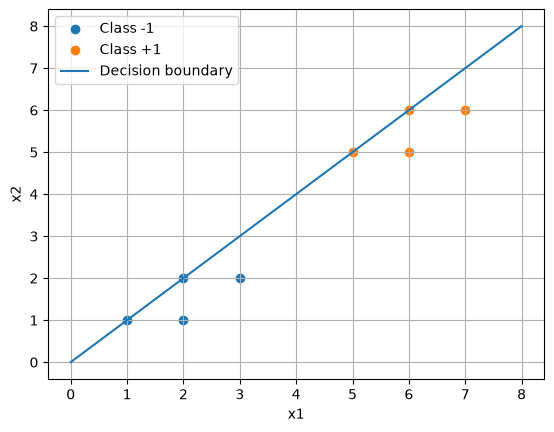

In [5]:
x1 = np.linspace(0, 8, 100)

x2 = -(w[0] * x1 + b) / w[1]

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Class -1"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class +1"
)

plt.plot(x1, x2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

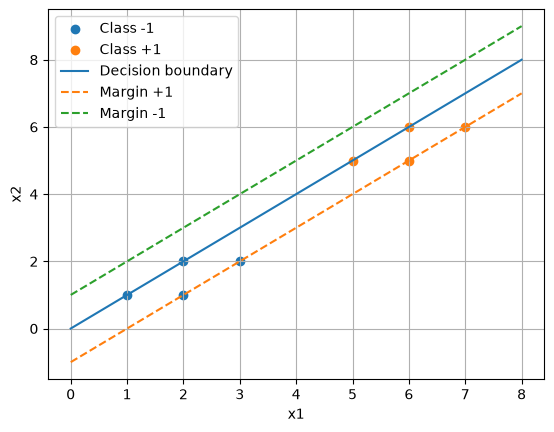

In [6]:
x1 = np.linspace(0, 8, 100)

decision = -(w[0] * x1 + b) / w[1]

margin_positive = (1 - w[0] * x1 - b) / w[1]

margin_negative = (-1 - w[0] * x1 - b) / w[1]

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Class -1"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class +1"
)

plt.plot(x1, decision, label="Decision boundary")
plt.plot(x1, margin_positive, "--", label="Margin +1")
plt.plot(x1, margin_negative, "--", label="Margin -1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

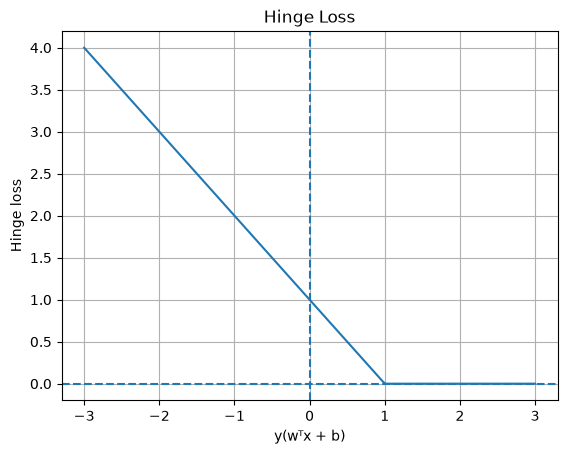

In [9]:
z = np.linspace(-3, 3, 200)

loss = np.maximum(0, 1 - z)

plt.plot(z, loss)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")

plt.xlabel("y(wᵀx + b)")
plt.ylabel("Hinge loss")
plt.title("Hinge Loss")

plt.grid()
plt.show()

In [10]:
from sklearn.svm import SVC


In [11]:

model = SVC(kernel="linear", C=1.0)

model.fit(X, y)

predictions = model.predict(X)

print(predictions)

[-1 -1 -1 -1  1  1  1  1]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


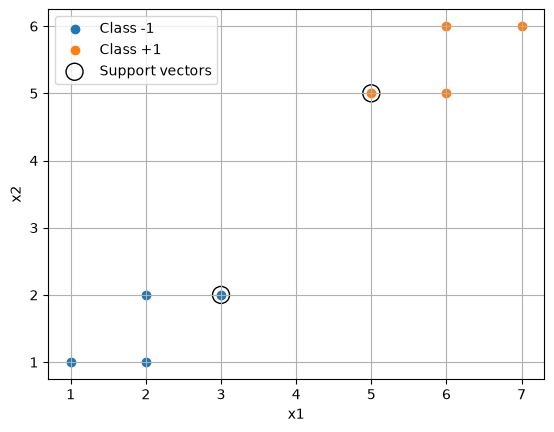

In [16]:
plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Class -1"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class +1"
)

support_vectors = model.support_vectors_

from sklearn.inspection import DecisionBoundaryDisplay


plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    label="Support vectors"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()